# Heart failure prediction model


## Loading data set

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
df=pd.read_csv('/content/heart_failure_clinical_records_dataset.csv')
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


## Exproring dataset

In [81]:
print(df.head())

    age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0  75.0        0                       582         0                 20   
1  55.0        0                      7861         0                 38   
2  65.0        0                       146         0                 20   
3  50.0        1                       111         0                 20   
4  65.0        1                       160         1                 20   

   high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex  \
0                    1  265000.00               1.9           130    1   
1                    0  263358.03               1.1           136    1   
2                    0  162000.00               1.3           129    1   
3                    0  210000.00               1.9           137    1   
4                    0  327000.00               2.7           116    0   

   smoking  time  DEATH_EVENT  
0        0     4            1  
1        0     6            1  
2       

In [82]:
print(df.shape)

(299, 13)


In [83]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB
None


In [84]:
print(df.isnull().sum())

age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


In [85]:
print(df.dtypes)

age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object


In [86]:
print(df.duplicated().sum())

0


## Splitting dataset as x and y

In [87]:
X = df.drop('DEATH_EVENT', axis=1)
Y= df['DEATH_EVENT']

In [88]:
print("X:")
print(X)

print("y:")
print(Y)

X:
      age  anaemia  creatinine_phosphokinase  diabetes  ejection_fraction  \
0    75.0        0                       582         0                 20   
1    55.0        0                      7861         0                 38   
2    65.0        0                       146         0                 20   
3    50.0        1                       111         0                 20   
4    65.0        1                       160         1                 20   
..    ...      ...                       ...       ...                ...   
294  62.0        0                        61         1                 38   
295  55.0        0                      1820         0                 38   
296  45.0        0                      2060         1                 60   
297  45.0        0                      2413         0                 38   
298  50.0        0                       196         0                 45   

     high_blood_pressure  platelets  serum_creatinine  serum_sodium  sex

In [89]:
print(Y.value_counts())

DEATH_EVENT
0    203
1     96
Name: count, dtype: int64


In [90]:
print(Y.value_counts(normalize=True))

DEATH_EVENT
0    0.67893
1    0.32107
Name: proportion, dtype: float64


## Data Visualization

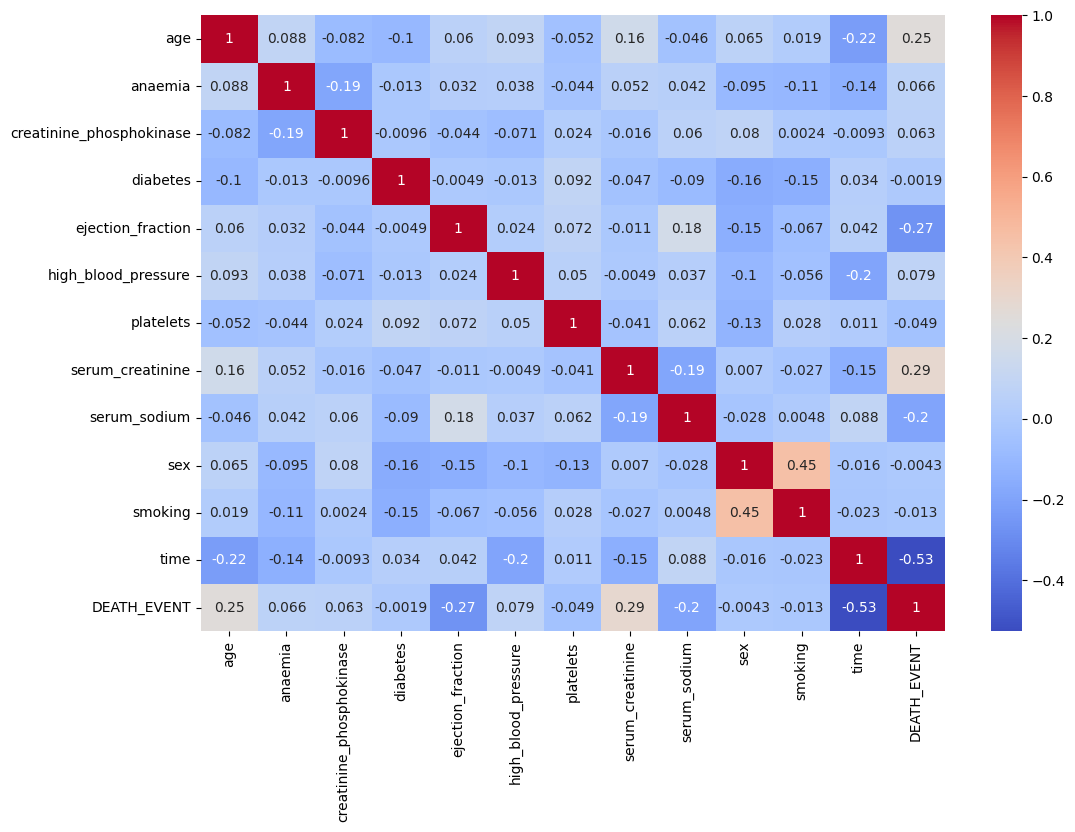

In [91]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

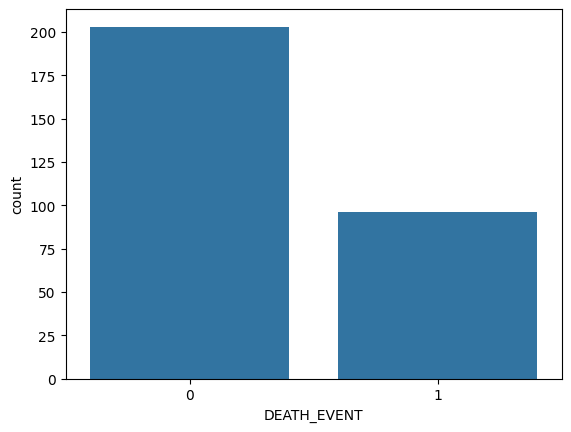

In [92]:
sns.countplot(x='DEATH_EVENT', data=df)
plt.show()

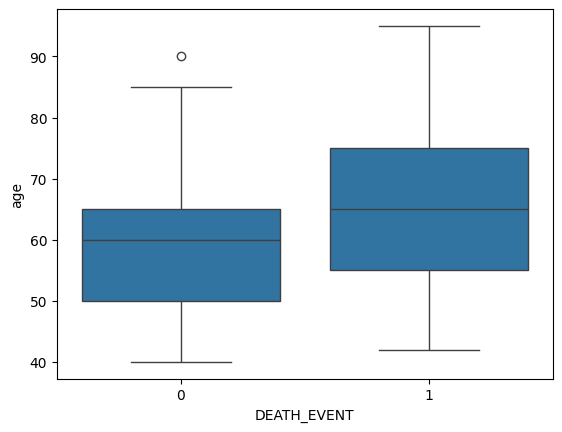

In [93]:
sns.boxplot(x='DEATH_EVENT', y='age', data=df)
plt.show()

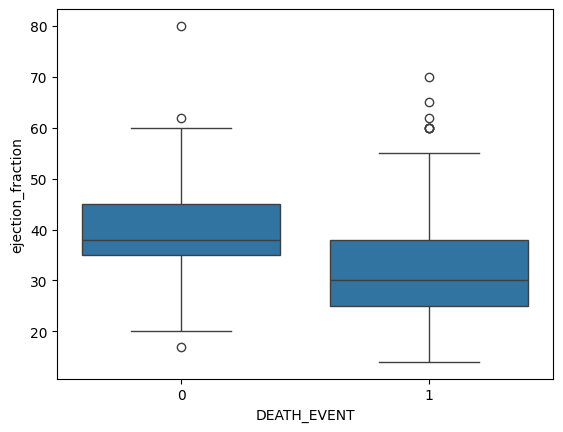

In [94]:
sns.boxplot(x='DEATH_EVENT', y='ejection_fraction', data=df)
plt.show()


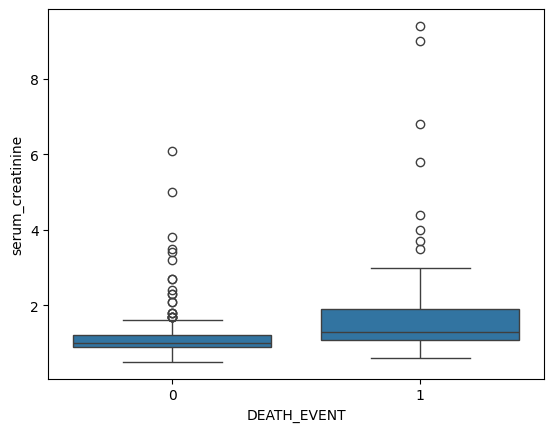

In [95]:
sns.boxplot(x='DEATH_EVENT', y='serum_creatinine', data=df)
plt.show()

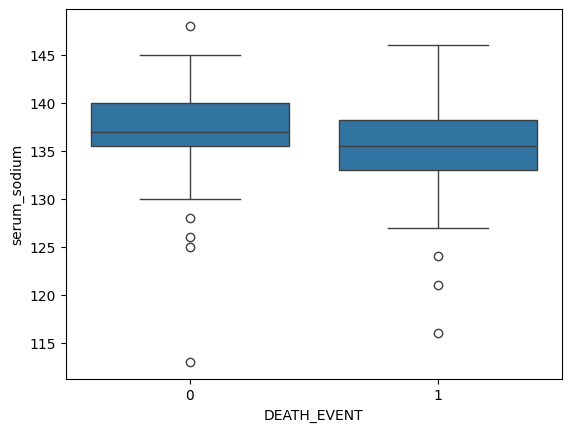

In [96]:
sns.boxplot(x='DEATH_EVENT', y='serum_sodium', data=df)
plt.show()

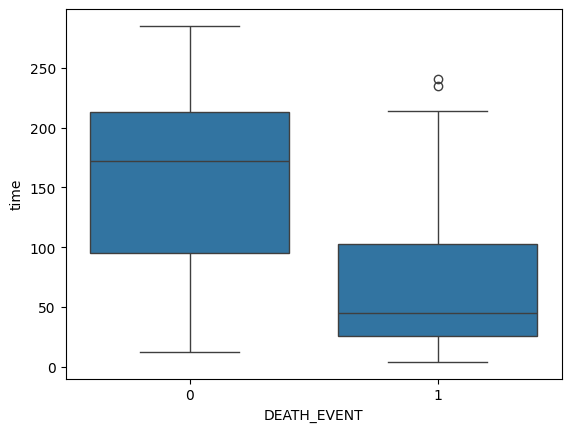

In [97]:
sns.boxplot(x='DEATH_EVENT', y='time', data=df)
plt.show()

## Model training

In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y)

In [99]:
print(X_train.shape)
print(X_test.shape)

(239, 12)
(60, 12)


## Random Forest

In [100]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, Y_train)

Y_pred_rf = rf_model.predict(X_test)

print(classification_report(Y_test, Y_pred_rf))
print(confusion_matrix(Y_test, Y_pred_rf))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88        41
           1       0.80      0.63      0.71        19

    accuracy                           0.83        60
   macro avg       0.82      0.78      0.79        60
weighted avg       0.83      0.83      0.83        60

[[38  3]
 [ 7 12]]


## Random Forest - without time feature

In [101]:
X_no_time = X.drop(columns=['time'])

In [102]:
from sklearn.model_selection import train_test_split

X_train_nt, X_test_nt, Y_train_nt, Y_test_nt = train_test_split(
    X_no_time,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_no_time = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_no_time.fit(X_train_nt, Y_train_nt)

Y_pred_nt = rf_no_time.predict(X_test_nt)

print(classification_report(Y_test_nt, Y_pred_nt))
print(confusion_matrix(Y_test_nt, Y_pred_nt))

              precision    recall  f1-score   support

           0       0.74      0.85      0.80        41
           1       0.54      0.37      0.44        19

    accuracy                           0.70        60
   macro avg       0.64      0.61      0.62        60
weighted avg       0.68      0.70      0.68        60

[[35  6]
 [12  7]]


## Random forest with threshold at 0.25

In [104]:
Y_prob_rf_nt = rf_no_time.predict_proba(X_test_nt)[:, 1]

In [105]:
Y_pred_rf_25 = (Y_prob_rf_nt >= 0.25).astype(int)

print(classification_report(Y_test_nt, Y_pred_rf_25))
print(confusion_matrix(Y_test_nt, Y_pred_rf_25))

              precision    recall  f1-score   support

           0       0.87      0.63      0.73        41
           1       0.50      0.79      0.61        19

    accuracy                           0.68        60
   macro avg       0.68      0.71      0.67        60
weighted avg       0.75      0.68      0.69        60

[[26 15]
 [ 4 15]]


## Save Final Model

In [106]:
import joblib

joblib.dump(rf_no_time, "heart_failure_model.pkl")

['heart_failure_model.pkl']

## Create Application

In [107]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("heart_failure_model.pkl")

st.title("Heart Failure Risk Prediction")
st.write("Enter the patient's clinical information below.")

age = st.number_input("Age", min_value=1, max_value=120, value=60)

anaemia = st.selectbox("Anaemia", ["No", "Yes"])
anaemia = 1 if anaemia == "Yes" else 0

creatinine_phosphokinase = st.number_input(
    "Creatinine Phosphokinase",
    min_value=0,
    value=250
)

diabetes = st.selectbox("Diabetes", ["No", "Yes"])
diabetes = 1 if diabetes == "Yes" else 0

ejection_fraction = st.number_input(
    "Ejection Fraction",
    min_value=0,
    max_value=100,
    value=38
)

high_blood_pressure = st.selectbox(
    "High Blood Pressure",
    ["No", "Yes"]
)
high_blood_pressure = 1 if high_blood_pressure == "Yes" else 0


platelets = st.number_input(
    "Platelets",
    min_value=0.0,
    value=250000.0
)

serum_creatinine = st.number_input(
    "Serum Creatinine",
    min_value=0.0,
    value=1.0
)

serum_sodium = st.number_input(
    "Serum Sodium",
    min_value=0.0,
    value=137.0
)

sex = st.selectbox("Sex", ["Female", "Male"])
sex = 1 if sex == "Male" else 0

smoking = st.selectbox("Smoking", ["No", "Yes"])
smoking = 1 if smoking == "Yes" else 0

if st.button("Predict Risk"):

    input_data = pd.DataFrame([[
        age,
        anaemia,
        creatinine_phosphokinase,
        diabetes,
        ejection_fraction,
        high_blood_pressure,
        platelets,
        serum_creatinine,
        serum_sodium,
        sex,
        smoking
    ]], columns=[
        'age',
        'anaemia',
        'creatinine_phosphokinase',
        'diabetes',
        'ejection_fraction',
        'high_blood_pressure',
        'platelets',
        'serum_creatinine',
        'serum_sodium',
        'sex',
        'smoking'
    ])

    probability = model.predict_proba(input_data)[0][1]

    if probability >= 0.25:
        st.error("Higher Risk of Death")
    else:
        st.success("Lower Risk of Death")

    st.write(f"Predicted probability: {probability:.2%}")

Overwriting app.py
